**Problem Statement**


The objective of this project is to analyze teaching assistant (TA) performance data from the University of Wisconsin–Madison and build a machine learning model that can accurately predict TA performance levels

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


In [10]:
df = pd.read_csv("/content/tae.csv", header=None)

In [11]:
df.columns = [
    "Native_teacher",
    "Instructor",
    "Course",
    "Semester",
    "Class_size",
    "Class"
]


In [12]:
df.head()

,Native_teacher,Instructor,Course,Semester,Class_size,Class
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3


In [15]:
df.shape

(151, 6)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Native_teacher  151 non-null    int64
 1   Instructor      151 non-null    int64
 2   Course          151 non-null    int64
 3   Semester        151 non-null    int64
 4   Class_size      151 non-null    int64
 5   Class           151 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


In [17]:
df.describe()

,Native_teacher,Instructor,Course,Semester,Class_size,Class
count,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000
mean,1.807947,13.642384,8.105960,1.847682,27.867550,2.019868
std,0.395225,6.825779,7.023914,0.360525,12.893758,0.820327
min,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000
25%,2.000000,8.000000,3.000000,2.000000,19.000000,1.000000
50%,2.000000,13.000000,4.000000,2.000000,27.000000,2.000000
75%,2.000000,20.000000,15.000000,2.000000,37.000000,3.000000
max,2.000000,25.000000,26.000000,2.000000,66.000000,3.000000


In [18]:
df.isnull().sum()

,0
Native_teacher,0
Instructor,0
Course,0
Semester,0
Class_size,0
Class,0


In [19]:
df["Class"].value_counts()


,count
Class,
3,52
2,50
1,49


✅ Dataset is clean, no missing values
✅ Target is multi-class (1,2,3)

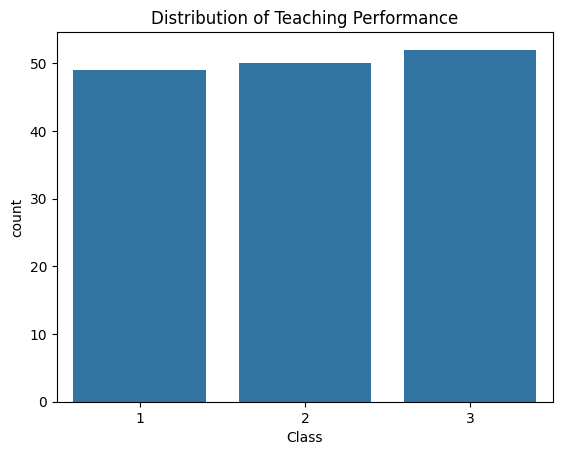

In [20]:
sns.countplot(x="Class", data=df)
plt.title("Distribution of Teaching Performance")
plt.show()


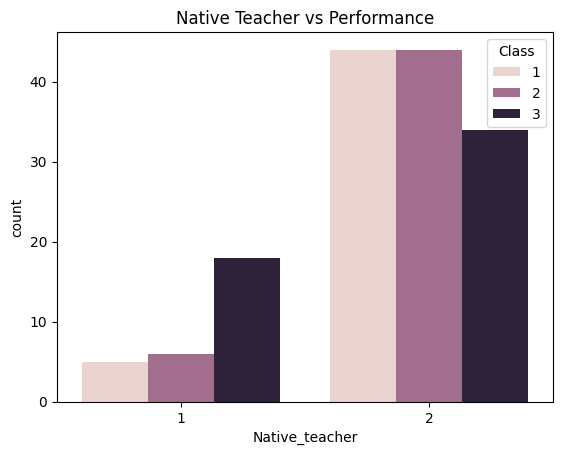

In [21]:
sns.countplot(x="Native_teacher", hue="Class", data=df)
plt.title("Native Teacher vs Performance")
plt.show()


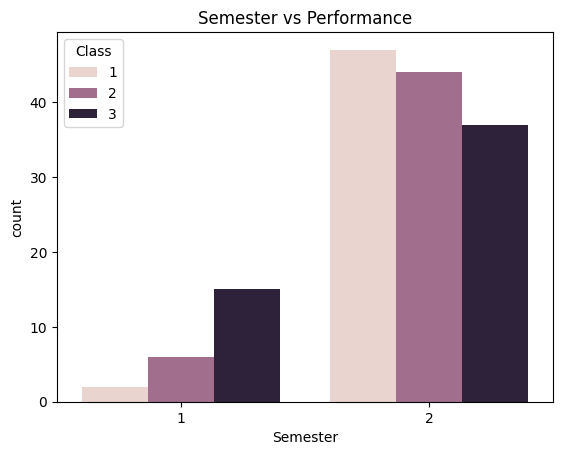

In [22]:
sns.countplot(x="Semester", hue="Class", data=df)
plt.title("Semester vs Performance")
plt.show()


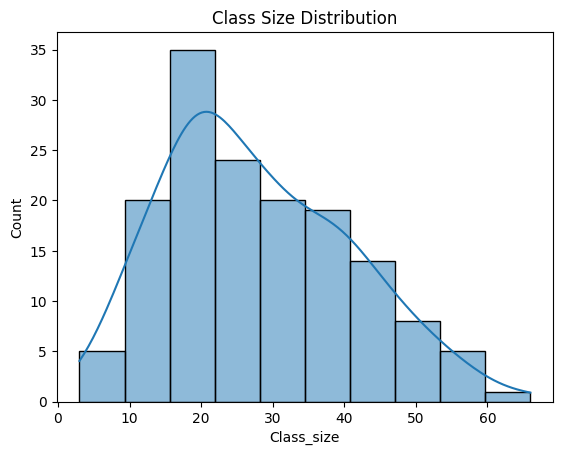

In [23]:
sns.histplot(df["Class_size"], kde=True)
plt.title("Class Size Distribution")
plt.show()


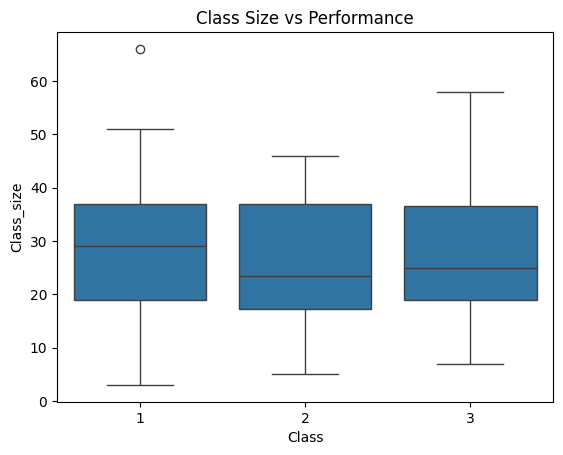

In [24]:
sns.boxplot(x="Class", y="Class_size", data=df)
plt.title("Class Size vs Performance")
plt.show()


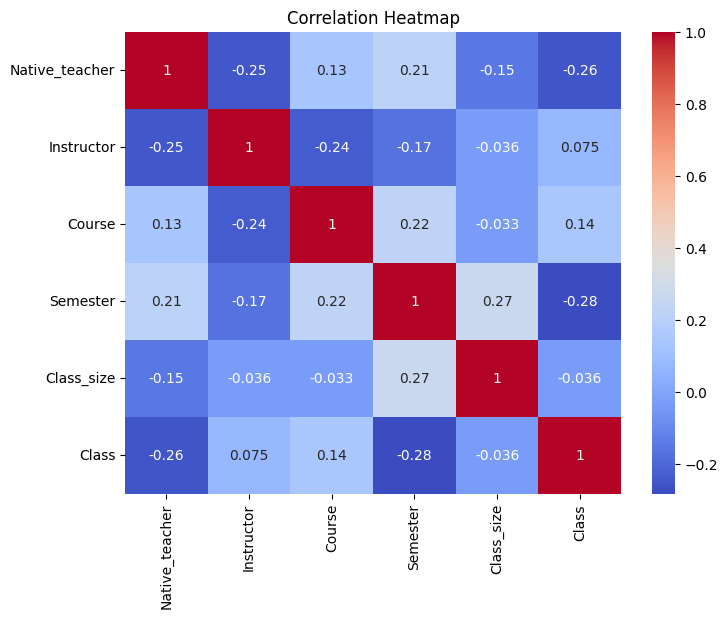

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [26]:
le = LabelEncoder()

df["Instructor"] = le.fit_transform(df["Instructor"])
df["Course"] = le.fit_transform(df["Course"])


In [27]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [28]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.6129032258064516
              precision    recall  f1-score   support

           1       0.58      0.70      0.64        10
           2       0.58      0.70      0.64        10
           3       0.71      0.45      0.56        11

    accuracy                           0.61        31
   macro avg       0.63      0.62      0.61        31
weighted avg       0.63      0.61      0.61        31



In [29]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.3870967741935484
              precision    recall  f1-score   support

           1       0.40      0.60      0.48        10
           2       0.38      0.50      0.43        10
           3       0.33      0.09      0.14        11

    accuracy                           0.39        31
   macro avg       0.37      0.40      0.35        31
weighted avg       0.37      0.39      0.35        31



In [30]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.6451612903225806
              precision    recall  f1-score   support

           1       0.64      0.70      0.67        10
           2       0.55      0.60      0.57        10
           3       0.78      0.64      0.70        11

    accuracy                           0.65        31
   macro avg       0.65      0.65      0.65        31
weighted avg       0.66      0.65      0.65        31



In [31]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=None
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.6451612903225806
              precision    recall  f1-score   support

           1       0.56      0.50      0.53        10
           2       0.54      0.70      0.61        10
           3       0.89      0.73      0.80        11

    accuracy                           0.65        31
   macro avg       0.66      0.64      0.65        31
weighted avg       0.67      0.65      0.65        31



In [32]:
model_scores = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

model_scores.sort_values(by="Accuracy", ascending=False)


,Model,Accuracy
3,Random Forest,0.645161
2,Decision Tree,0.645161
0,Logistic Regression,0.612903
1,KNN,0.387097


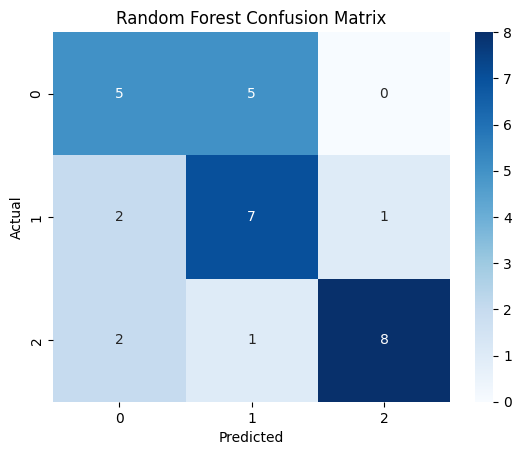

In [33]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


**Challenges Faced**


| Challenge            | Technique Used                    |
| -------------------- | --------------------------------- |
| Small dataset        | Stratified split, ensemble models |
| Categorical overload | Label Encoding                    |
| Multi-class output   | F1-score, confusion matrix        |
| Overfitting risk     | Random Forest                     |
| Model comparison     | Accuracy + classification report  |


**Final Conclusion**

Random Forest achieved the highest accuracy

Handles categorical features well

Less overfitting compared to Decision Tree

Best choice for production deployment